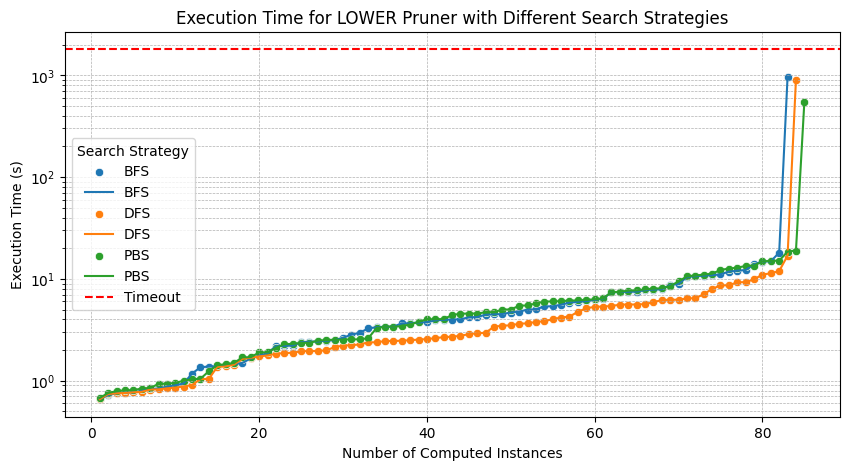

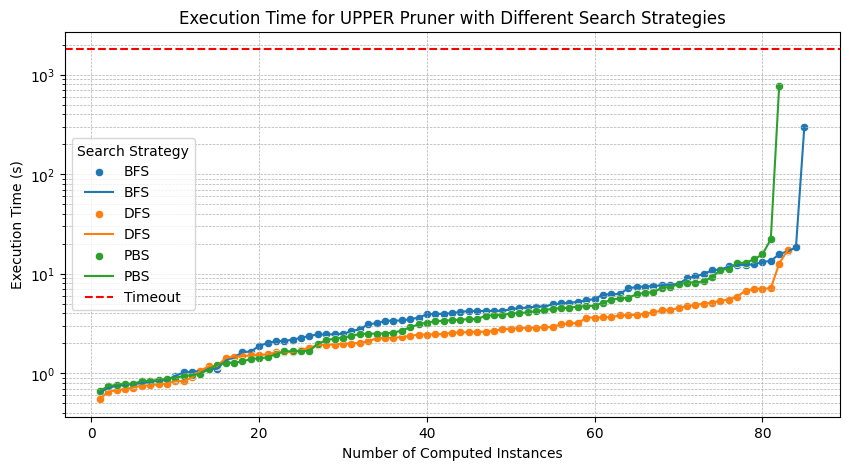

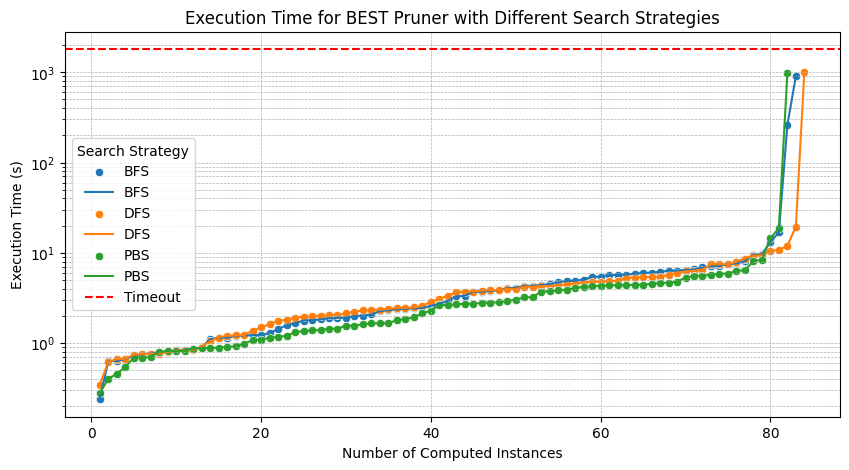

<Figure size 1400x800 with 0 Axes>

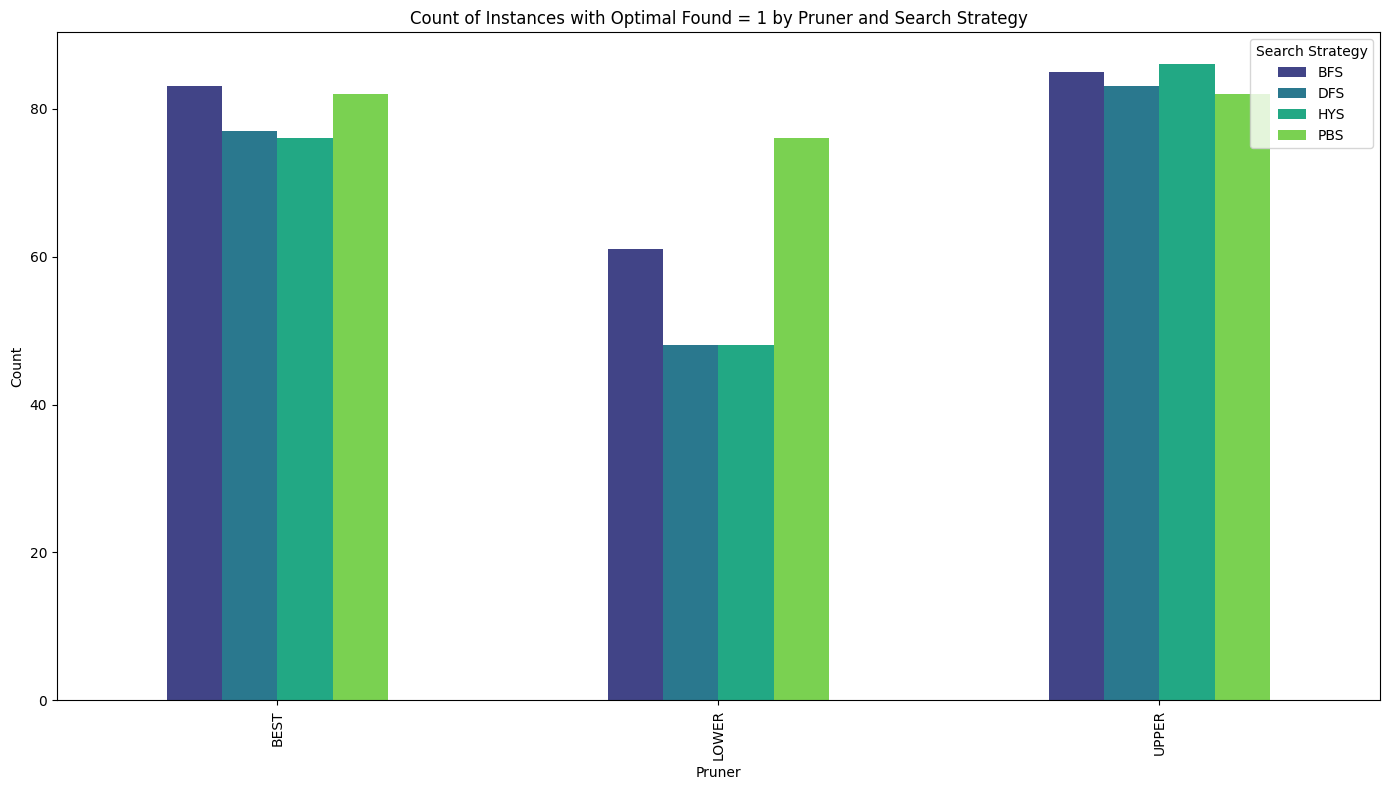

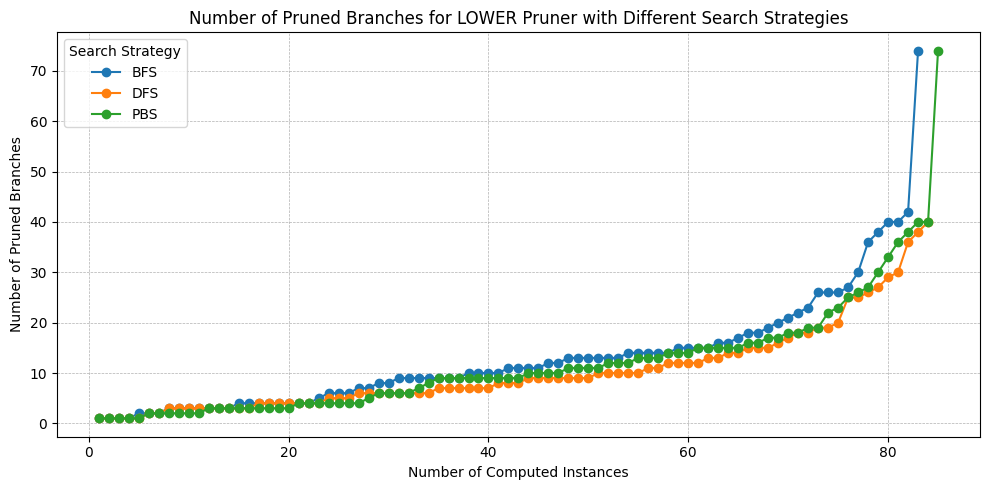

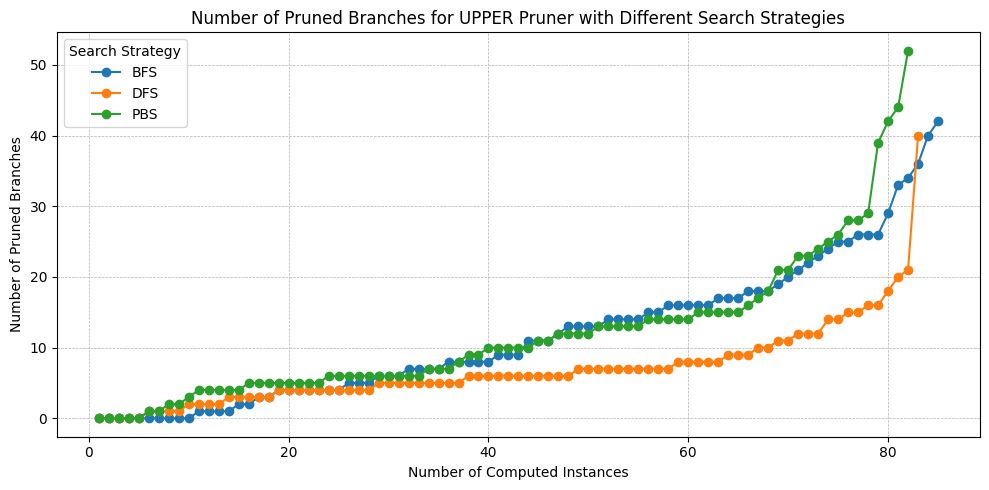

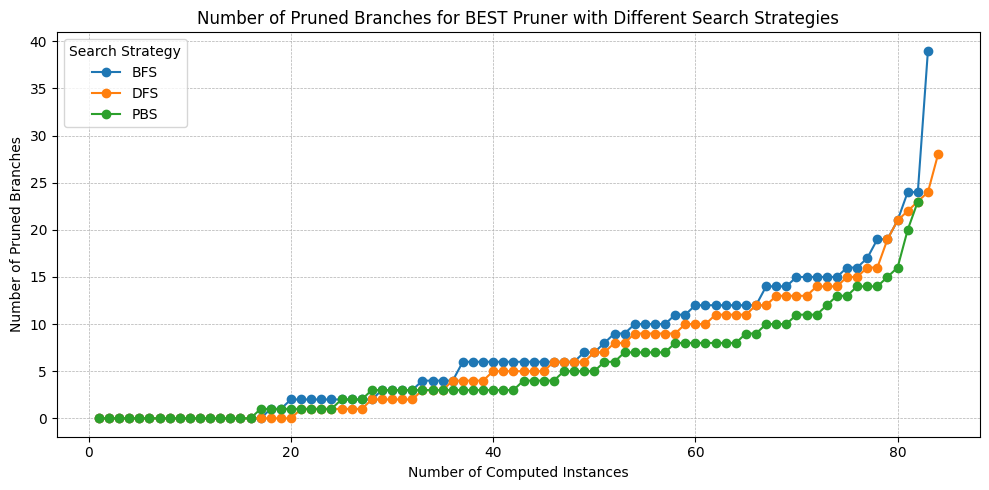

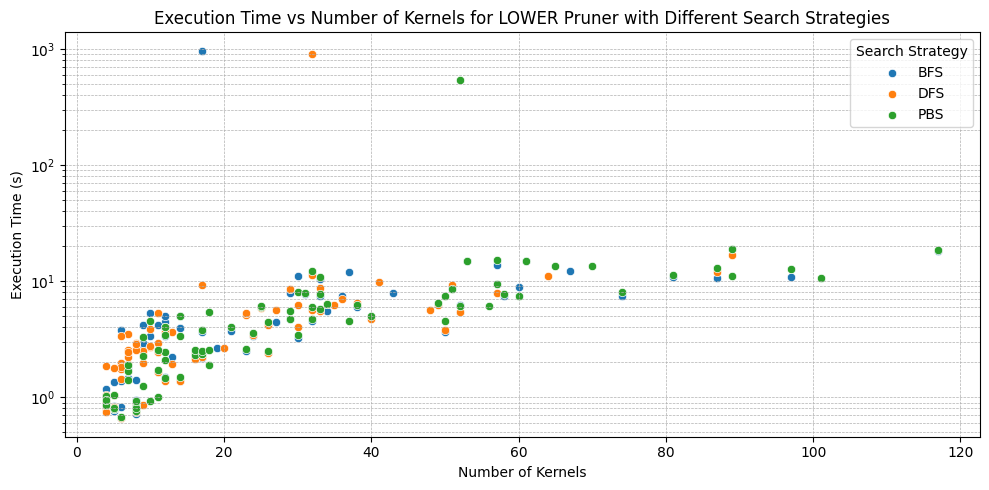

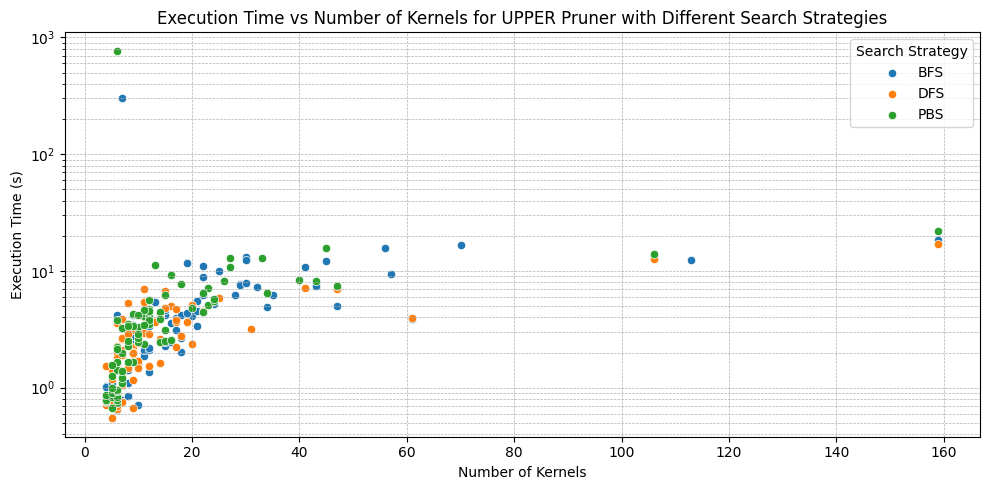

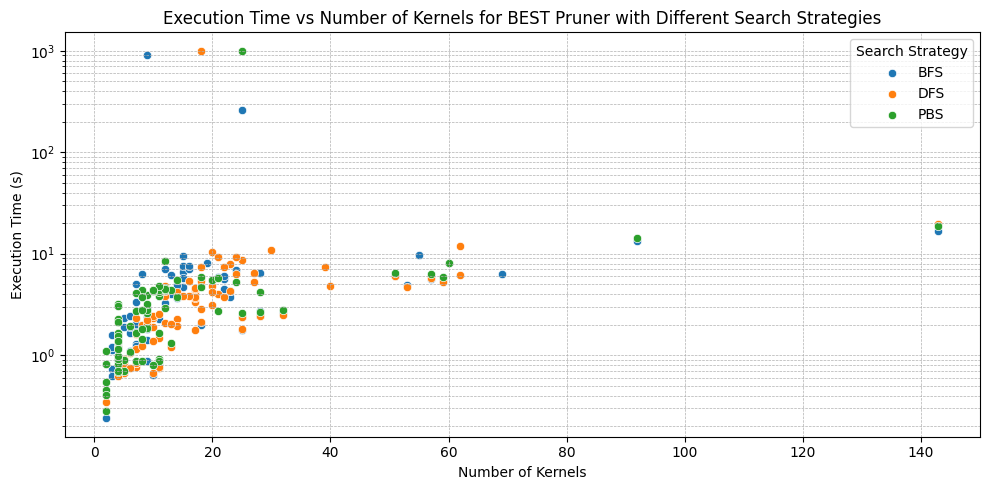

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# Drop all existing dataframes
for name in dir():
    if isinstance(eval(name), pd.core.frame.DataFrame):
        del globals()[name]

# Run garbage collection to free up memory
gc.collect()

# Load the CSV file into a new Pandas DataFrame
file_path = '240731_RESALL_SEARCHES.csv'  # Replace with your file path
df_all_searches = pd.read_csv(file_path, delimiter=';', quotechar='"')

# Define the pruners and search strategies
pruners = ['LOWER', 'UPPER', 'BEST']
search_strategies = ['BFS', 'DFS', 'HYB', 'PBS']

# Plotting execution time for each pruner with different search strategies
for pruner in pruners:
    plt.figure(figsize=(10, 5))
    
    for strategy in search_strategies:
        subset = df_all_searches[(df_all_searches['pruner'] == pruner) & 
                                 (df_all_searches['search_strategy'] == strategy)]
        if not subset.empty:
            # Sort the subset by execution_time
            subset = subset.sort_values(by='execution_time')
            # Create a counter for the x-axis based on the sorted order
            subset['counter'] = range(1, len(subset) + 1)
            
            # Plot the scatter points
            sns.scatterplot(
                x='counter', 
                y='execution_time', 
                data=subset,
                marker='o', 
                label=strategy  # Use strategy as label
            )
            
            # Plot the lines connecting the points
            plt.plot(
                subset['counter'], 
                subset['execution_time'], 
                linestyle='-', 
                label=strategy
            )
    
    # Add a horizontal line for the timeout threshold (if applicable)
    timeout_threshold = 1800  # Adjust this threshold as needed
    plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')
    
    # Customize the plot
    plt.yscale('log')  # Set y-axis to logarithmic scale
    plt.title(f'Execution Time for {pruner} Pruner with Different Search Strategies')
    plt.xlabel('Number of Computed Instances')
    plt.ylabel('Execution Time (s)')
    plt.legend(title='Search Strategy')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Save or display the plot
    plt.savefig(f'exe_time_{pruner.lower()}_pruner.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot the count of instances with optimal_found = 1 for each pruner and search strategy
optimal_found_counts = df_all_searches[df_all_searches['optimal_found'] == 1].groupby(['pruner', 'search_strategy']).size().unstack(fill_value=0)

# Create a bar plot for the counts
plt.figure(figsize=(14, 8))
optimal_found_counts.plot(kind='bar', stacked=False, figsize=(14, 8), color=sns.color_palette('viridis', len(search_strategies)))

# Customize the plot
plt.title('Count of Instances with Optimal Found = 1 by Pruner and Search Strategy')
plt.xlabel('Pruner')
plt.ylabel('Count')
plt.legend(title='Search Strategy')
plt.grid(False)  # Disable grid on the bar chart

# Save or display the plot
plt.tight_layout()
plt.savefig('EVAL_optimal_found_counts_by_pruner_and_search_strategy.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the number of pruned branches over the number of instances for each pruner and search strategy
for pruner in pruners:
    plt.figure(figsize=(10, 5))
    
    for strategy in search_strategies:
        subset = df_all_searches[(df_all_searches['pruner'] == pruner) & 
                                 (df_all_searches['search_strategy'] == strategy)]
        if not subset.empty:
            # Sort the subset by pruned_branches
            subset = subset.sort_values(by='pruned_branches')
            # Create a counter for the x-axis based on the sorted order
            subset['counter'] = range(1, len(subset) + 1)
            
            # Plot the lines connecting the points
            plt.plot(
                subset['counter'], 
                subset['pruned_branches'], 
                linestyle='-', 
                marker='o',
                label=strategy
            )
    
    # Customize the plot
    plt.title(f'Number of Pruned Branches for {pruner} Pruner with Different Search Strategies')
    plt.xlabel('Number of Computed Instances')
    plt.ylabel('Number of Pruned Branches')
    plt.legend(title='Search Strategy')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Save or display the plot
    plt.tight_layout()
    plt.savefig(f'EVAL_pruned_branches_{pruner.lower()}_pruner.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot the execution time compared to the number of kernels for each pruner and search strategy
for pruner in pruners:
    plt.figure(figsize=(10, 5))
    
    for strategy in search_strategies:
        subset = df_all_searches[(df_all_searches['pruner'] == pruner) & 
                                 (df_all_searches['search_strategy'] == strategy)]
        if not subset.empty:
            # Plot the scatter points
            sns.scatterplot(
                x='num_kernels', 
                y='execution_time', 
                data=subset,
                marker='o', 
                label=strategy
            )
    
    # Customize the plot
    plt.yscale('log')  # Set y-axis to logarithmic scale
    plt.title(f'Execution Time vs Number of Kernels for {pruner} Pruner with Different Search Strategies')
    plt.xlabel('Number of Kernels')
    plt.ylabel('Execution Time (s)')
    plt.legend(title='Search Strategy')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Save or display the plot
    plt.tight_layout()
    plt.savefig(f'EVAL_execution_time_vs_num_kernels_{pruner.lower()}_pruner.png', dpi=300, bbox_inches='tight')
    plt.show()


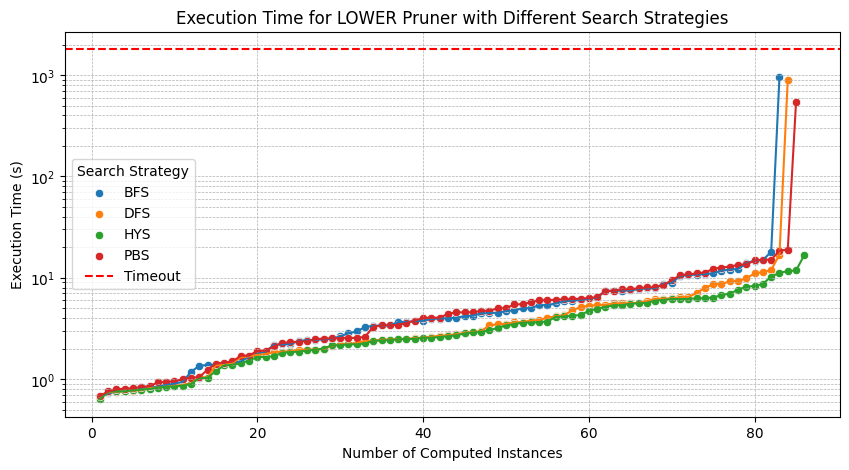

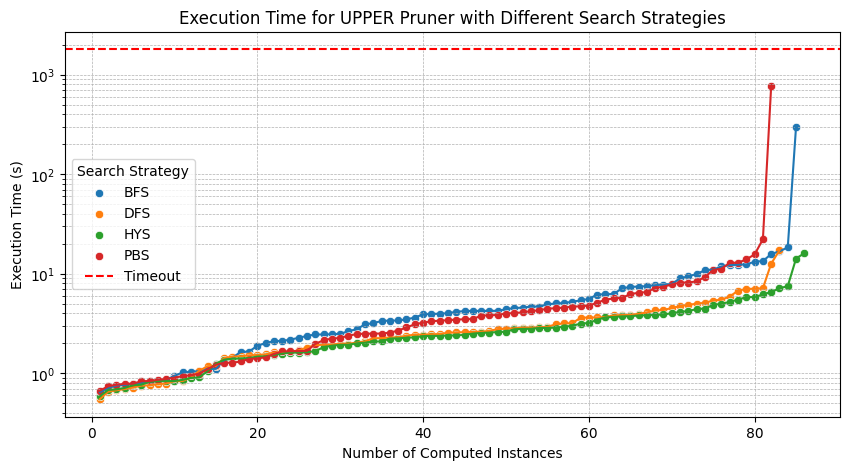

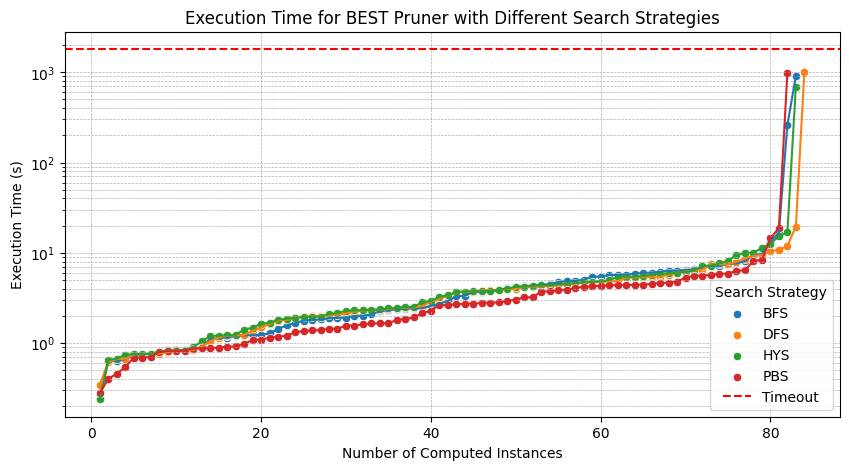

<Figure size 1400x800 with 0 Axes>

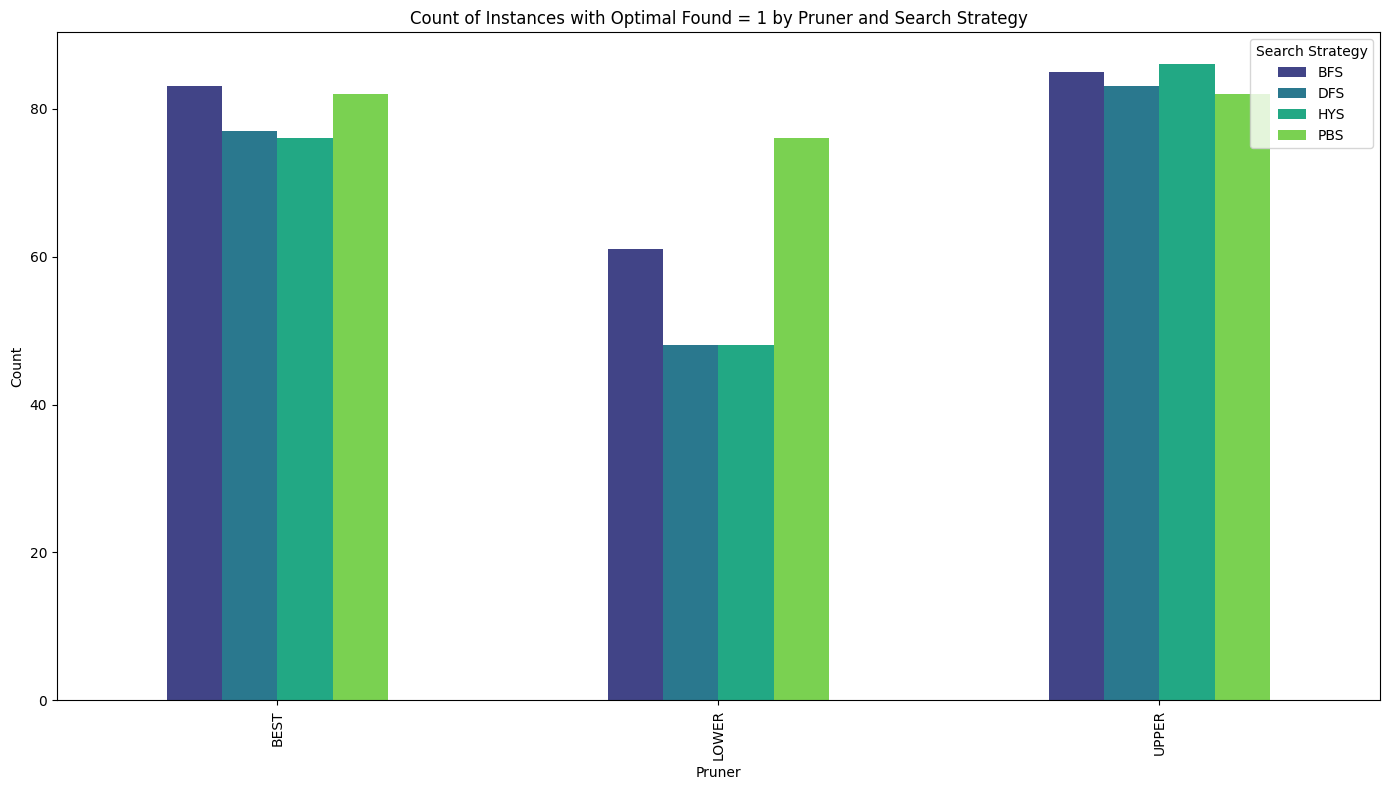

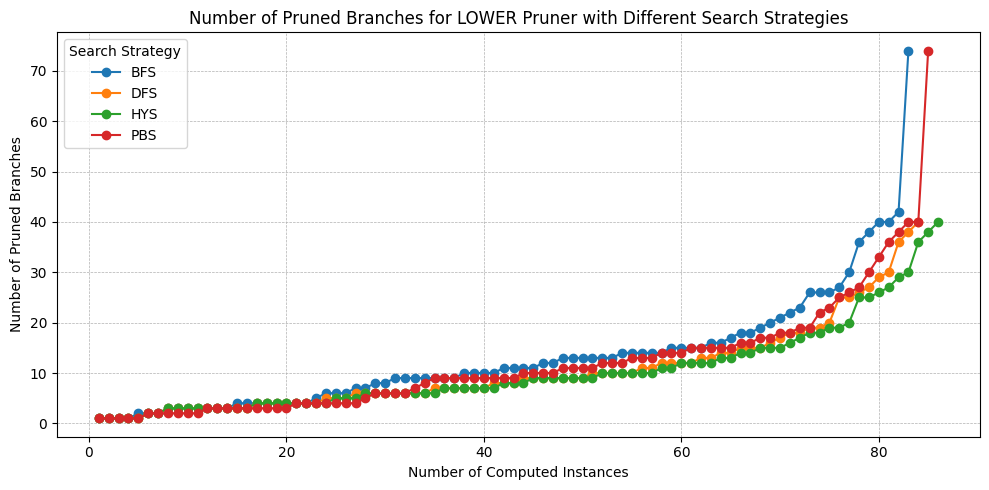

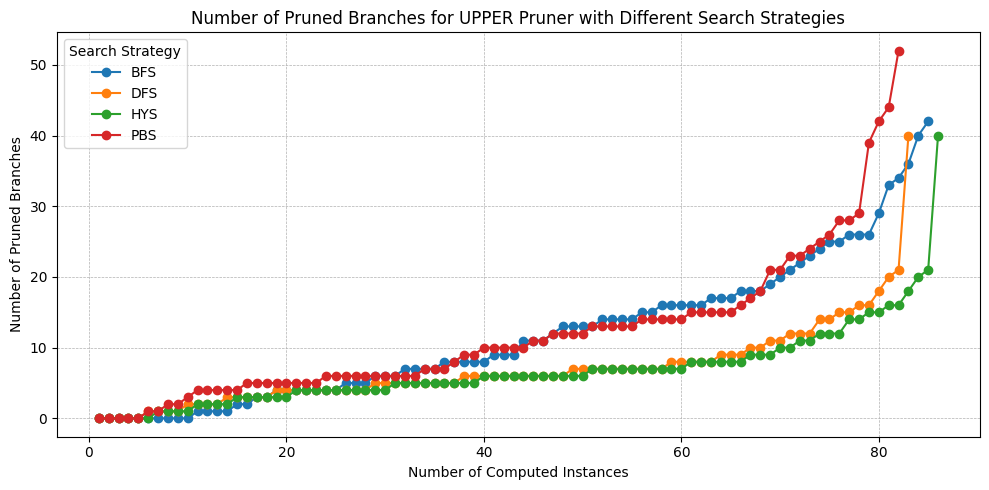

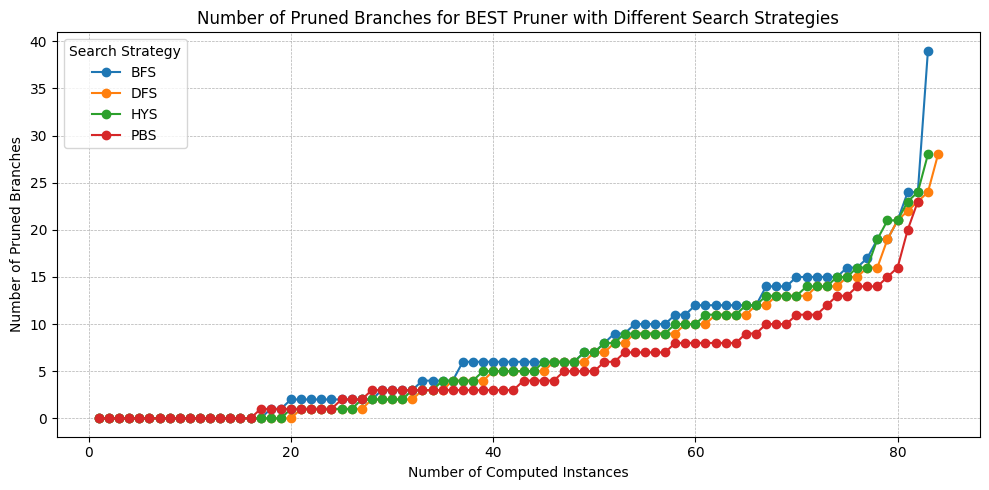

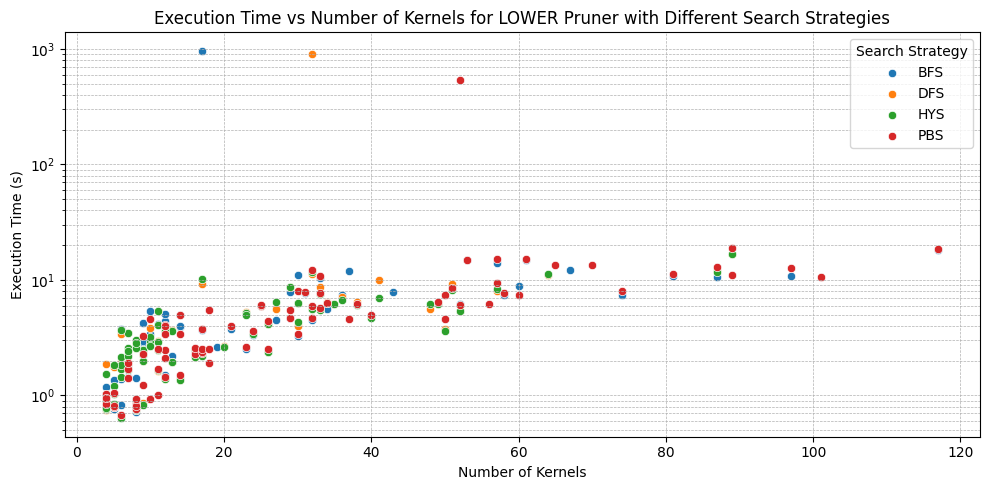

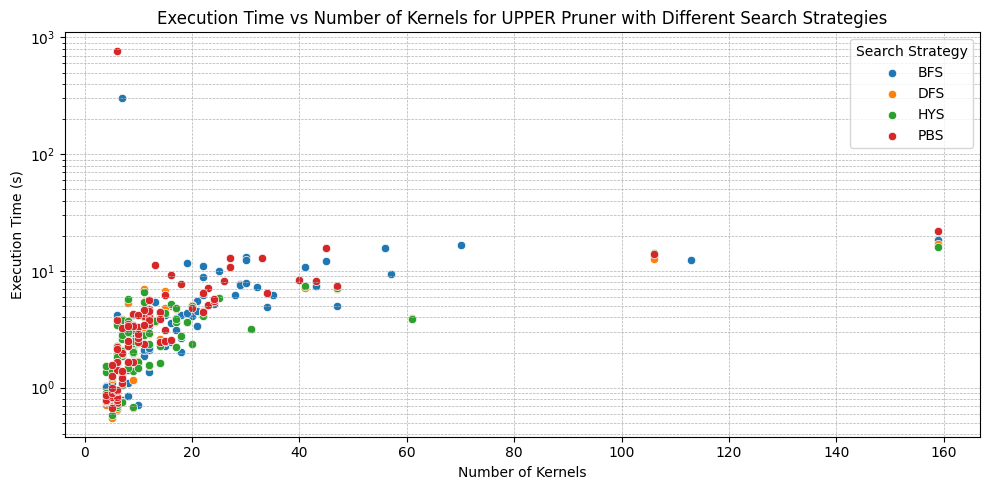

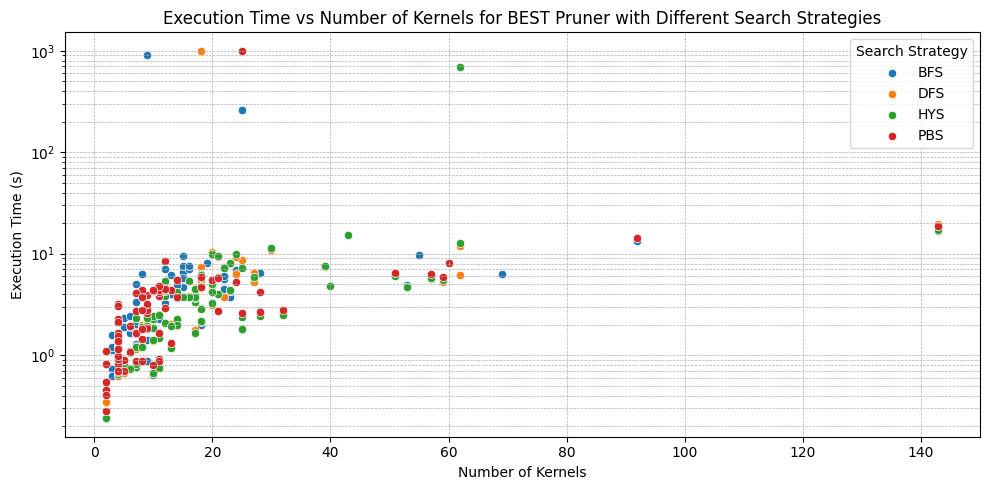

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc

# Drop all existing dataframes
for name in dir():
    if isinstance(eval(name), pd.core.frame.DataFrame):
        del globals()[name]

# Run garbage collection to free up memory
gc.collect()

# Load the CSV file into a new Pandas DataFrame
file_path = '240731_RESALL_SEARCHES.csv'  # Replace with your file path
df_all_searches = pd.read_csv(file_path, delimiter=';', quotechar='"')

# Define the pruners and search strategies
pruners = ['LOWER', 'UPPER', 'BEST']
search_strategies = ['BFS', 'DFS', 'HYS', 'PBS']

# Plotting execution time for each pruner with different search strategies
for pruner in pruners:
    plt.figure(figsize=(10, 5))
    
    for strategy in search_strategies:
        subset = df_all_searches[(df_all_searches['pruner'] == pruner) & 
                                 (df_all_searches['search_strategy'] == strategy)]
        if not subset.empty:
            # Sort the subset by execution_time
            subset = subset.sort_values(by='execution_time')
            # Create a counter for the x-axis based on the sorted order
            subset['counter'] = range(1, len(subset) + 1)
            
            # Plot the scatter points
            sns.scatterplot(
                x='counter', 
                y='execution_time', 
                data=subset,
                marker='o', 
                label=strategy  # Use strategy as label
            )
    
    # Plot the lines separately to avoid duplicate legends
    for strategy in search_strategies:
        subset = df_all_searches[(df_all_searches['pruner'] == pruner) & 
                                 (df_all_searches['search_strategy'] == strategy)]
        if not subset.empty:
            # Sort the subset by execution_time
            subset = subset.sort_values(by='execution_time')
            # Create a counter for the x-axis based on the sorted order
            subset['counter'] = range(1, len(subset) + 1)
            
            # Plot the lines connecting the points
            plt.plot(
                subset['counter'], 
                subset['execution_time'], 
                linestyle='-', 
                label='_nolegend_'  # Do not add to legend
            )
    
    # Add a horizontal line for the timeout threshold (if applicable)
    timeout_threshold = 1800  # Adjust this threshold as needed
    plt.axhline(y=timeout_threshold, color='red', linestyle='--', label='Timeout')
    
    # Customize the plot
    plt.yscale('log')  # Set y-axis to logarithmic scale
    plt.title(f'Execution Time for {pruner} Pruner with Different Search Strategies')
    plt.xlabel('Number of Computed Instances')
    plt.ylabel('Execution Time (s)')
    plt.legend(title='Search Strategy')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Save or display the plot
    plt.savefig(f'exe_time_{pruner.lower()}_pruner.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot the count of instances with optimal_found = 1 for each pruner and search strategy
optimal_found_counts = df_all_searches[df_all_searches['optimal_found'] == 1].groupby(['pruner', 'search_strategy']).size().unstack(fill_value=0)

# Create a bar plot for the counts
plt.figure(figsize=(14, 8))
optimal_found_counts.plot(kind='bar', stacked=False, figsize=(14, 8), color=sns.color_palette('viridis', len(search_strategies)))

# Customize the plot
plt.title('Count of Instances with Optimal Found = 1 by Pruner and Search Strategy')
plt.xlabel('Pruner')
plt.ylabel('Count')
plt.legend(title='Search Strategy')
plt.grid(False)  # Disable grid on the bar chart

# Save or display the plot
plt.tight_layout()
plt.savefig('EVAL_optimal_found_counts_by_pruner_and_search_strategy.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot the number of pruned branches over the number of instances for each pruner and search strategy
for pruner in pruners:
    plt.figure(figsize=(10, 5))
    
    for strategy in search_strategies:
        subset = df_all_searches[(df_all_searches['pruner'] == pruner) & 
                                 (df_all_searches['search_strategy'] == strategy)]
        if not subset.empty:
            # Sort the subset by pruned_branches
            subset = subset.sort_values(by='pruned_branches')
            # Create a counter for the x-axis based on the sorted order
            subset['counter'] = range(1, len(subset) + 1)
            
            # Plot the lines connecting the points
            plt.plot(
                subset['counter'], 
                subset['pruned_branches'], 
                linestyle='-', 
                marker='o',
                label=strategy
            )
    
    # Customize the plot
    plt.title(f'Number of Pruned Branches for {pruner} Pruner with Different Search Strategies')
    plt.xlabel('Number of Computed Instances')
    plt.ylabel('Number of Pruned Branches')
    plt.legend(title='Search Strategy')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Save or display the plot
    plt.tight_layout()
    plt.savefig(f'EVAL_pruned_branches_{pruner.lower()}_pruner.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot the execution time compared to the number of kernels for each pruner and search strategy
for pruner in pruners:
    plt.figure(figsize=(10, 5))
    
    for strategy in search_strategies:
        subset = df_all_searches[(df_all_searches['pruner'] == pruner) & 
                                 (df_all_searches['search_strategy'] == strategy)]
        if not subset.empty:
            # Plot the scatter points
            sns.scatterplot(
                x='num_kernels', 
                y='execution_time', 
                data=subset,
                marker='o', 
                label=strategy
            )
    
    # Customize the plot
    plt.yscale('log')  # Set y-axis to logarithmic scale
    plt.title(f'Execution Time vs Number of Kernels for {pruner} Pruner with Different Search Strategies')
    plt.xlabel('Number of Kernels')
    plt.ylabel('Execution Time (s)')
    plt.legend(title='Search Strategy')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Save or display the plot
    plt.tight_layout()
    plt.savefig(f'EVAL_execution_time_vs_num_kernels_{pruner.lower()}_pruner.png', dpi=300, bbox_inches='tight')
    plt.show()
